**[🏠 Course Home](00_START_HERE.ipynb) | ◀️ Previous: [Sheet 3: Rapid Prototyping — Quadratic (Laplace / QUAP) Approximation](03_quadratic_laplace_approximation.ipynb) | ▶️ Next: [Sheet 4: First Principles — MCMC Mechanics from Scratch](04_mcmc_mechanics_from_scratch.ipynb)**

---

# Sheet 3b: Discrete Markov Chains, Stationary Equilibrium & Detailed Balance (R Track)
### *Demystifying Probability Flows, Transition Matrices, and the Equilibrium Engine That Powers MCMC*

---

## 🧭 The Learning Progression
* **[Sheet 3: Rapid Prototyping — Quadratic (Laplace) Approximation](03_quadratic_laplace_approximation.ipynb)**: Fast parabolic fitting near the mode $\hat{\theta}_{\text{MAP}}$, using the inverse Hessian matrix $\Sigma = H^{-1}$ with `optim(..., hessian=TRUE)` or `rethinking::quap()`.
* **👉 Sheet 3b (You are here)**: The conceptual missing link — what is a **Markov Chain**, how do **transition matrices** propagate probabilities, why do chains converge to a **unique stationary distribution**, and what is **Detailed Balance**?
* **[Sheet 4: First Principles — MCMC Mechanics from Scratch](04_mcmc_mechanics_from_scratch.ipynb)**: Translating these discrete principles into continuous Metropolis-Hastings random walks in pure Base R.

> [!NOTE]
> ### 🗺️ The Big Picture: Where We Are on the Mountain
> * **The Boss Battle**: In Bayesian statistics, finding the posterior $P(\theta \mid y) = \frac{\mathcal{L}(y \mid \theta) P(\theta)}{P(y)}$ requires calculating the denominator $P(y) = \int \mathcal{L} P \, d\theta$—an intractable high-dimensional integral across parameter space.
> * **How We Got Here**:
>   1. **Conjugacy (Sheets 1 & 1b)**: Solved the integral analytically on paper, but works only for toy textbook models.
>   2. **Grid Approximation (Sheet 2)**: Evaluated the posterior across a grid, but died from the Curse of Dimensionality ($100^{10} = 10^{20}$ points in 10D).
>   3. **Laplace / QUAP (Sheet 3)**: Fitted a fast Gaussian dome over the mode, but failed on parameter boundaries ($\sigma > 0$), skew, and multimodality.
> * **The Mission of Sheet 3b**: To prove the mathematical foundation of **Markov Chains** and **Detailed Balance**—revealing *why* an intelligent random walker can sample accurately from any target distribution without *ever* calculating the intractable denominator $P(y)$!
> * **Where This Leads**: In **Sheet 4**, we take the Detailed Balance transition engine proven here and build the continuous **Metropolis-Hastings algorithm from scratch**.

---

## 🎯 The Pedagogical Challenge: Why This Sheet Exists

In many Bayesian textbooks, students encounter this sentence with zero preparation:
> *"A Markov chain reaches a stationary distribution $\pi(\theta)$ if the probability flow between every pair of states $A$ and $B$ is in exact equilibrium (**Detailed Balance**):*
> $$\pi(A) \cdot T(A \to B) = \pi(B) \cdot T(B \to A)$$
> *where $T(A \to B)$ is the transition probability from state $A$ to state $B$."*

This formula often feels like magic. Questions immediately arise:
1. What exactly is "flowing" between states?
2. Why does balance between *individual pairs* guarantee that the *entire distribution* stops changing?
3. How can a random walker hopping blindly between states ever reconstruct the exact Bayesian posterior distribution?

This notebook answers those questions from **first principles**, starting with simple 3-island discrete examples and progressing to the exact mathematical trick that powers all of MCMC.

---

## Table of Contents
1. **Part 1: The Core Intuition — The Memoryless Walker & The 3 Islands**
   - The Markov Property: The Future Depends Only on the Present
   - The State Space and the Transition Matrix ($P$)
2. **Part 2: Simulating Random Walks vs. Exact Distribution Propagation**
   - Individual Stochastic Walkers in Base R (`sample()`)
   - Vector-Matrix Dynamics: $\pi_t = \pi_0 P^t$
   - The Convergence Phenomenon: Different Starts, Same Equilibrium
3. **Part 3: The Stationary Distribution ($\pi^*$) & The Eigenvector Duality**
   - Definition of Invariance: $\pi^* P = \pi^*$
   - Finding $\pi^*$ via Linear Algebra in R (`eigen(t(P))` & `solve()`)
   - The Ergodic Theorem: Irreducibility & Aperiodicity
4. **Part 4: Probability Flows & The Law of Detailed Balance**
   - Defining Directional Flow: $\text{Flow}(A \to B) = \pi(A) P_{AB}$
   - Global Balance (Total Inflow = Total Outflow) vs. Detailed Balance (Pairwise Symmetry)
   - Mathematical Proof: Why Detailed Balance Guarantees Stationarity
5. **Part 5: The Grand Bridge to MCMC — The "Inverse Problem"**
   - Forward Problem (Markov Chains) vs. Inverse Problem (Bayesian Sampling)
   - The Metropolis Hack: Designing Transitions from Unnormalized Posteriors
   - Step-by-Step Proof of Detailed Balance in Metropolis-Hastings
   - Building a Discrete Metropolis Sampler from Scratch in Base R
6. **Part 6: Check Your Understanding (3-Tier Exercises)**
   - 🟢 Tier 1 (Conceptual): Unnormalized Potentials & Detailed Balance
   - 🟡 Tier 2 (Guided Calculation): The Two-Room Equilibrium
   - 🔴 Tier 3 (Production Challenge): An Automated Detailed Balance Auditor in R

---

## Part 1: The Core Intuition — The Memoryless Walker & The 3 Islands

### 1.1 The Markov Property: "No Memory of Yesterday"
A stochastic process $X_0, X_1, X_2, \dots$ possesses the **Markov property** if the probability of the next state depends **only on the current state**, not on how it got there:

$$P(X_{t+1} = s_{t+1} \mid X_t = s_t, X_{t-1} = s_{t-1}, \dots, X_0 = s_0) = P(X_{t+1} = s_{t+1} \mid X_t = s_t)$$

Think of a frog hopping between lily pads: the frog doesn't care which pads it visited 10 minutes ago; its next hop depends purely on where its feet are right now.

---

### 1.2 The State Space ($S$) & The Transition Matrix ($P$)
Imagine a cluster of three islands:
* **Island 1**
* **Island 2**
* **Island 3**

> **Definition of $K$ (The State Space Size)**:  
> We denote the total number of distinct states in the system by **$K$**.  
> In this island example, **$K = 3$**, and the discrete state space is $\mathcal{S} = \{1, 2, \dots, K\}$.

A traveler hops between these $K$ islands once per day according to fixed probabilities. We can organize all transition rules into a **Transition Matrix** $P$, where:
$$P_{ij} = P(X_{t+1} = j \mid X_t = i) = \text{Probability of jumping from Island } i \text{ to Island } j$$

*(Notation note: In general probability and MCMC literature, you will also see this written in functional notation as **$T(i \to j) \equiv P_{ij}$**, where **$T$** stands for **Transition**).*

Let our island transition matrix in R be:
$$P = \begin{pmatrix} 
0.60 & 0.30 & 0.10 \\ 
0.20 & 0.50 & 0.30 \\ 
0.15 & 0.35 & 0.50 
\end{pmatrix}$$

> **Two Fundamental Rules of Transition Matrices (Row-Stochastic)**:
> 1. **Non-negativity**: Every entry $P_{ij} \ge 0$.
> 2. **Rows sum to 1**: From any state $i$, you must go to one of the $K$ destination states (or stay): $\sum_{j=1}^K P_{ij} = 1.0$ for each row $i$.

---

#### Example: A One-Step Multiplication Update ($\pi_1 = \pi_0 P$)
How does the transition matrix $P$ update our belief about the traveler's location after one step?

Suppose on **Day 0** ($t = 0$), we know with certainty that the traveler starts on **Island 1**. We represent this initial state as a row probability vector $\pi_0$:
$$\pi_0 = \begin{pmatrix} 1.0 & 0.0 & 0.0 \end{pmatrix}$$

To find the probability distribution on **Day 1** ($t = 1$), we perform a **one-step vector-matrix multiplication**:
$$\pi_1 = \pi_0 P = \begin{pmatrix} 1.0 & 0.0 & 0.0 \end{pmatrix} \begin{pmatrix} 
0.60 & 0.30 & 0.10 \\ 
0.20 & 0.50 & 0.30 \\ 
0.15 & 0.35 & 0.50 
\end{pmatrix} = \begin{pmatrix} 0.60 & 0.30 & 0.10 \end{pmatrix}$$
*(Notice that when starting deterministically in state $i$, $\pi_0 P$ simply extracts row $i$ of the transition matrix).*

Now suppose our starting location is uncertain—represented by a prior probability distribution where the traveler has a $50\%$ chance of starting on Island 1, $30\%$ on Island 2, and $20\%$ on Island 3:
$$\pi_0 = \begin{pmatrix} 0.50 & 0.30 & 0.20 \end{pmatrix}$$

The one-step multiplication update applies the **Law of Total Probability** across all possible origins:
$$\pi_1(j) = \sum_{i=1}^K \pi_0(i) P_{ij}$$

Carrying out the vector-matrix multiplication $\pi_1 = \pi_0 P$:
$$\pi_1 = \begin{pmatrix} 0.50 & 0.30 & 0.20 \end{pmatrix} \begin{pmatrix} 
0.60 & 0.30 & 0.10 \\ 
0.20 & 0.50 & 0.30 \\ 
0.15 & 0.35 & 0.50 
\end{pmatrix}$$

$$\begin{aligned}
\pi_1(1) &= (0.50 \times 0.60) + (0.30 \times 0.20) + (0.20 \times 0.15) = 0.30 + 0.06 + 0.03 = \mathbf{0.39} \quad (39\%) \\
\pi_1(2) &= (0.50 \times 0.30) + (0.30 \times 0.50) + (0.20 \times 0.35) = 0.15 + 0.15 + 0.07 = \mathbf{0.37} \quad (37\%) \\
\pi_1(3) &= (0.50 \times 0.10) + (0.30 \times 0.30) + (0.20 \times 0.50) = 0.05 + 0.09 + 0.10 = \mathbf{0.24} \quad (24\%)
\end{aligned}$$

$$\pi_1 = \begin{pmatrix} 0.39 & 0.37 & 0.24 \end{pmatrix}$$

The resulting probabilities sum to exactly $1.0$ ($0.39 + 0.37 + 0.24 = 1.00$). In a single matrix multiplication, the entire probability distribution updates forward by one time step!

In [1]:
# Set seed for reproducible simulations
set.seed(42)

states <- c("Island 1", "Island 2", "Island 3")
K <- length(states)

# Construct transition matrix P (byrow = TRUE so rows represent origins)
P <- matrix(c(
  0.60, 0.30, 0.10,  # From Island 1
  0.20, 0.50, 0.30,  # From Island 2
  0.15, 0.35, 0.50   # From Island 3
), nrow = 3, byrow = TRUE)

dimnames(P) <- list(From = states, To = states)

cat("--- State Transition Matrix P ---\n")
print(round(P, 2))

# Verify row sums
cat("\nRow sums (must all equal 1.0):\n")
print(rowSums(P))
stopifnot(isTRUE(all.equal(unname(rowSums(P)), rep(1.0, K))))

# Example: One-Step Multiplication Update (pi_1 = pi_0 %*% P)
pi_0 <- c(0.50, 0.30, 0.20)
pi_1 <- as.vector(pi_0 %*% P)

cat("\n--- Example: One-Step Multiplication Update ---\n")
cat("pi_0 (Day 0):", pi_0, "\n")
cat("pi_1 (Day 1):", round(pi_1, 4), "\n")
stopifnot(isTRUE(all.equal(sum(pi_1), 1.0)))

--- State Transition Matrix P ---


          To
From       Island 1 Island 2 Island 3
  Island 1     0.60     0.30      0.1
  Island 2     0.20     0.50      0.3
  Island 3     0.15     0.35      0.5



Row sums (must all equal 1.0):


Island 1 Island 2 Island 3 
       1        1        1 



--- Example: One-Step Multiplication Update ---


pi_0 (Day 0): 0.5 0.3 0.2 


pi_1 (Day 1): 0.39 0.37 0.24 


---

## Part 2: Simulating Random Walks vs. Exact Distribution Propagation

There are two completely different, complementary ways to analyze a Markov chain:
1. **The Stochastic View (Sample Paths)**: Follow a single physical walker jumping from island to island with random dice rolls (`sample()`).
2. **The Deterministic View (Probability Vectors)**: Track an entire swarm of millions of walkers simultaneously using linear algebra.

---

### 2.1 The Deterministic View: Propagating Probability Vectors
Let $\pi_t = [\pi_t(1), \pi_t(2), \dots, \pi_t(K)]$ be a row vector representing the probability distribution of where a walker is at time step $t$.

By the Law of Total Probability:
$$\pi_{t+1}(j) = \sum_{i=1}^K \pi_t(i) P_{ij} \implies \mathbf{\pi_{t+1} = \pi_t P}$$

Applying this recursively from initial state distribution $\pi_0$:
$$\mathbf{\pi_t = \pi_0 P^t}$$

Let us simulate both views side by side: deterministic distribution propagation from two contrasting initial states, alongside a single stochastic 10,000-step random walker.


--- Exact Stationary Distribution from Matrix Powers (t = 25) ---


  Island 1   : 0.3085 (30.9%)
  Island 2   : 0.3936 (39.4%)
  Island 3   : 0.2979 (29.8%)



--- 10,000-Step Random Walker Visit Frequencies ---


  Island 1   : 0.3021 (30.2%)
  Island 2   : 0.3957 (39.6%)
  Island 3   : 0.3022 (30.2%)


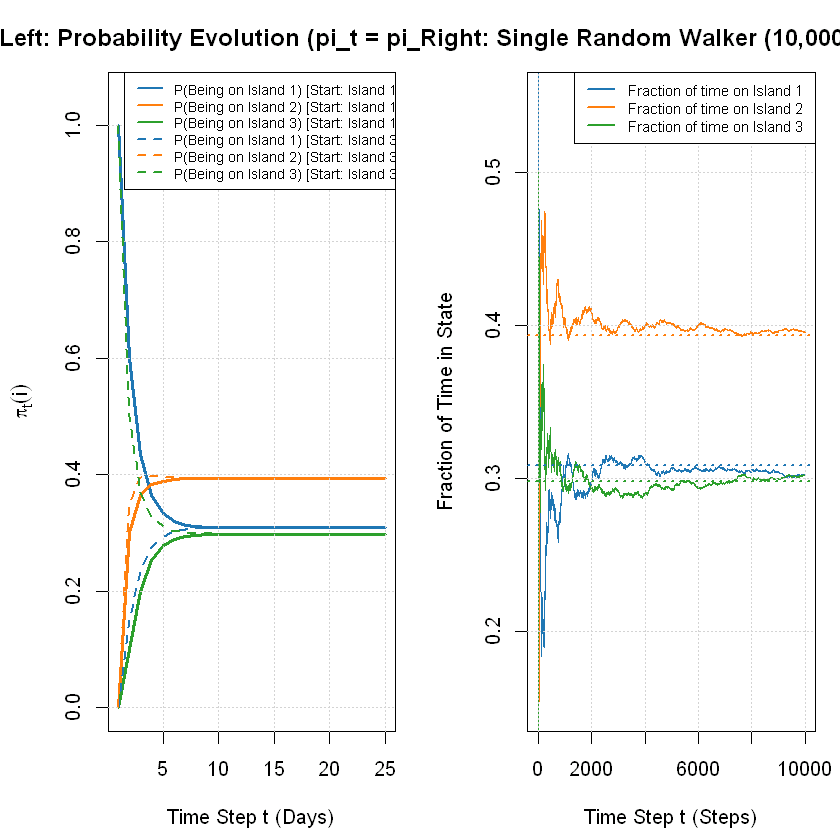

In [2]:
# 1. Deterministic propagation of probability vectors
n_steps <- 25
pi_A <- matrix(0, nrow = n_steps, ncol = K)
pi_B <- matrix(0, nrow = n_steps, ncol = K)

pi_A[1, ] <- c(1.0, 0.0, 0.0)  # Scenario A: Start 100% on Island 1
pi_B[1, ] <- c(0.0, 0.0, 1.0)  # Scenario B: Start 100% on Island 3

for (t in 2:n_steps) {
  pi_A[t, ] <- pi_A[t - 1, , drop = FALSE] %*% P
  pi_B[t, ] <- pi_B[t - 1, , drop = FALSE] %*% P
}

# 2. Stochastic simulation of an individual walker
simulate_walk <- function(P, initial_state = 1, steps = 10000) {
  chain <- integer(steps)
  chain[1] <- initial_state
  for (t in 2:steps) {
    curr <- chain[t - 1]
    chain[t] <- sample(1:K, size = 1, prob = P[curr, ])
  }
  return(chain)
}

walk <- simulate_walk(P, initial_state = 1, steps = 10000)
empirical_freqs <- prop.table(table(factor(walk, levels = 1:K)))

# Plotting with Base R
par(mfrow = c(1, 2), mar = c(4.5, 4.5, 3, 1))

# Subplot 1: Deterministic Distribution Propagation
plot(1:n_steps, pi_A[, 1], type = "l", col = "#1f77b4", lwd = 2.5,
     ylim = c(0, 1.05), xlab = "Time Step t (Days)", ylab = expression(pi[t](i)),
     main = "Left: Probability Evolution (pi_t = pi_0 * P^t)")
lines(1:n_steps, pi_A[, 2], col = "#ff7f0e", lwd = 2.5)
lines(1:n_steps, pi_A[, 3], col = "#2ca02c", lwd = 2.5)

lines(1:n_steps, pi_B[, 1], col = "#1f77b4", lwd = 2, lty = 2)
lines(1:n_steps, pi_B[, 2], col = "#ff7f0e", lwd = 2, lty = 2)
lines(1:n_steps, pi_B[, 3], col = "#2ca02c", lwd = 2, lty = 2)
grid()
legend("topright", legend = c("P(Being on Island 1) [Start: Island 1]", "P(Being on Island 2) [Start: Island 1]", "P(Being on Island 3) [Start: Island 1]",
                              "P(Being on Island 1) [Start: Island 3]", "P(Being on Island 2) [Start: Island 3]", "P(Being on Island 3) [Start: Island 3]"),
       col = c("#1f77b4", "#ff7f0e", "#2ca02c", "#1f77b4", "#ff7f0e", "#2ca02c"),
       lty = c(1, 1, 1, 2, 2, 2), lwd = 2, cex = 0.7, bg = "white")

# Subplot 2: Single Stochastic Walker Cumulative Visit Frequencies
cum_freq_1 <- cumsum(walk == 1) / (1:length(walk))
cum_freq_2 <- cumsum(walk == 2) / (1:length(walk))
cum_freq_3 <- cumsum(walk == 3) / (1:length(walk))

plot(1:length(walk), cum_freq_1, type = "l", col = "#1f77b4", lwd = 1.5,
     ylim = c(0.15, 0.55), xlab = "Time Step t (Steps)", ylab = "Fraction of Time in State",
     main = "Right: Single Random Walker (10,000 steps)")
lines(1:length(walk), cum_freq_2, col = "#ff7f0e", lwd = 1.5)
lines(1:length(walk), cum_freq_3, col = "#2ca02c", lwd = 1.5)
abline(h = pi_A[n_steps, 1], col = "#1f77b4", lty = 3, lwd = 2)
abline(h = pi_A[n_steps, 2], col = "#ff7f0e", lty = 3, lwd = 2)
abline(h = pi_A[n_steps, 3], col = "#2ca02c", lty = 3, lwd = 2)
grid()
legend("topright", legend = c("Fraction of time on Island 1", "Fraction of time on Island 2", "Fraction of time on Island 3"),
       col = c("#1f77b4", "#ff7f0e", "#2ca02c"), lty = 1, lwd = 2, cex = 0.75, bg = "white")

par(mfrow = c(1, 1))

cat("--- Exact Stationary Distribution from Matrix Powers (t = 25) ---\n")
for (i in 1:K) {
  cat(sprintf("  %-10s : %.4f (%.1f%%)\n", states[i], pi_A[n_steps, i], pi_A[n_steps, i] * 100))
}

cat("\n--- 10,000-Step Random Walker Visit Frequencies ---\n")
for (i in 1:K) {
  cat(sprintf("  %-10s : %.4f (%.1f%%)\n", states[i], empirical_freqs[i], empirical_freqs[i] * 100))
}

#### What are the graphs above telling you? (How to Read the Lines)

To test whether the starting point matters, we simulate two completely opposite starting scenarios:
* **Scenario A (Solid lines —)**: The traveler starts $100\%$ on **Island 1** ($\pi_0 = [1, 0, 0]$).
* **Scenario B (Dashed lines - -)**: The traveler starts $100\%$ on **Island 3** ($\pi_0 = [0, 0, 1]$).

| Line Color | Meaning | Starting from Island 1 (Solid —) | Starting from Island 3 (Dashed - -) | Long-Run Equilibrium ($\pi^*$) |
| :--- | :--- | :---: | :---: | :---: |
| 🔵 **Blue** | Probability of being on **Island 1** | Starts at $1.0$ $\to$ drops | Starts at $0.0$ $\to$ climbs | $\approx 30.9\%$ |
| 🟠 **Orange** | Probability of being on **Island 2** | Starts at $0.0$ $\to$ climbs | Starts at $0.0$ $\to$ climbs | $\approx 39.4\%$ |
| 🟢 **Green** | Probability of being on **Island 3** | Starts at $0.0$ $\to$ climbs | Starts at $1.0$ $\to$ drops | $\approx 29.8\%$ |

> **The Core "Aha!" Insight (Left Graph)**:  
> Look at **Day 8 to 10**: The solid and dashed lines of the **same color merge together**!  
> Whether you start on Island 1 or Island 3, by Day 8 the probability distribution is identical. **A Markov chain completely forgets its initial starting point.**
>
> **The Core "Aha!" Insight (Right Graph)**:  
> A single random walker hopping for 10,000 steps produces noisy empirical visit percentages (solid lines) that **lock directly onto the exact mathematical equilibrium lines (dotted $\dots$)**. We don't need to compute matrix powers; a wandering computer program naturally reconstructs the true distribution!

---

## Part 3: The Stationary Distribution ($\pi^*$) & The Eigenvector Duality

Notice what happened in the plots above:
* Regardless of whether the traveler started on **Island 1** or **Island 3**, by day 10 both paths merged into the **exact same distribution**:
  $$\pi^* \approx [0.3085, \; 0.3936, \; 0.2979]$$
* Once the chain arrives at $\pi^*$, multiplying by $P$ again changes nothing: $\pi^* P = \pi^*$.

This distribution is called the **Stationary (or Invariant) Distribution**.

---

### 3.1 The Mathematical Definition of Stationarity
A probability distribution vector $\pi^* = [\pi_1, \pi_2, \dots, \pi_K]$ is stationary with respect to transition matrix $P$ if:

$$\mathbf{\pi^* P = \pi^*} \quad \text{subject to} \quad \sum_{i=1}^K \pi_i = 1, \; \pi_i \ge 0$$

Look closely at this equation from linear algebra:
$$\pi^* P = 1 \cdot \pi^*$$

* $\pi^*$ is a **left eigenvector** of $P$ with eigenvalue $\lambda = 1$!
* Equivalently, taking the transpose:
  $$P^T (\pi^*)^T = 1 \cdot (\pi^*)^T \iff (P^T - \mathbf{I}) (\pi^*)^T = \mathbf{0}$$
  So the stationary vector lies in the **null space** of $(P^T - \mathbf{I})$.

---

### 3.2 When Does a Unique Stationary Distribution Exist? (The Ergodic Theorem)

Why are we so confident that our island chain—or an MCMC algorithm sampling a 50-dimensional Bayesian posterior—will converge to **one and only one** stationary distribution, regardless of where it starts?

The mathematical foundation is the **Fundamental Theorem of Markov Chains (The Ergodic Theorem)**.

> ### 🏛️ The Three Pillars of Ergodic MCMC
>
> | 1. Irreducibility | 2. Aperiodicity | 3. Positive Recurrence |
> | :---: | :---: | :---: |
> | *"Every parameter mode can be visited"* | *"Avoids lockstep oscillating cycles"* | *"Probability mass stays contained"* |
> | $\forall \, i, j \in \mathcal{S}, \; \exists \, n \ge 1: (P^n)_{ij} > 0$ | $d(i) = \gcd \{ n \ge 1 : (P^n)_{ii} > 0 \} = 1$ | $\mathbb{E}[T_i] < \infty \iff \int q(\theta) \, d\theta < \infty$ |
>
> $$\Downarrow$$
>
> ### 🎯 The Ergodic Equilibrium Guarantees
> 1. **Distribution Convergence (Limiting Distribution)**:
>    $$\lim_{t \to \infty} \pi_0 P^t = \pi^* \quad \text{for ANY initial distribution } \pi_0$$
> 2. **Strong Law of Large Numbers (Time Average = Space Average)**:
>    $$\lim_{N \to \infty} \frac{1}{N} \sum_{t=1}^N g(\theta^{(t)}) = \mathbb{E}_{\pi^*}[g(\theta)] \quad \text{(Sample Mean converges to exact Posterior Expectation)}$$

---

#### 1. The Three Structural Conditions for Ergodicity

A discrete-time Markov chain on a finite state space $\mathcal{S} = \{1, \dots, K\}$ is **ergodic** if it satisfies three structural properties:

##### Condition A: Irreducibility (Strong Connectivity)
> **Definition**: A Markov chain is **irreducible** if every state can eventually reach every other state in a finite number of steps with positive probability:
> $$\forall \, i, j \in \mathcal{S}, \; \exists \, n \ge 1 \quad \text{such that} \quad (P^n)_{ij} > 0$$

* **Graph-Theoretic Interpretation**: The directed state transition graph is **strongly connected**—there are no isolated state clusters or one-way dead ends (absorbing states).
* **What breaks if violated?**  
  If the state space splits into two disconnected subsets $S_1$ and $S_2$ with no paths between them:
  $$P = \begin{pmatrix} 1.0 & 0.0 \\ 0.0 & 1.0 \end{pmatrix}$$
  Then **infinitely many stationary distributions exist**! Any convex combination $\pi = [w, 1-w]$ satisfies $\pi P = \pi$. Where the chain ends up depends permanently on where it started. In Bayesian MCMC, this corresponds to a sampler trapped in an isolated local posterior mode, failing to explore the global parameter space.

```text
  [Irreducible / Strongly Connected]                  [Reducible / Disconnected Traps]
       Valid: Unique Equilibrium                         Broken: Multi-Modal Traps

        ┌─────────────┐                                   ┌─────────────┐
        │  Island 1   │◄─────────┐                        │   Mode 1    │◄─────────┐
        └──┬───────▲──┘          │                        └──┬───────▲──┘          │
      0.30 │       │ 0.20        │ 0.15                 0.50 │       │ 0.50        │
           ▼       │             │                           ▼       │             │
        ┌──────────┴──┐          │                        ┌──────────┴──┐          │
        │  Island 2   │          │                        │   Mode 2    │──────────┘
        └──┬───────▲──┘          │                        └─────────────┘
      0.30 │       │ 0.35        │                       (Trapped in 1 & 2 loop!)
           ▼       │             │
        ┌──────────┴──┐          │                             X  No path between
        │  Island 3   │──────────┘                             X  sub-graphs!
        └─────────────┘
      (Every state reachable)                             ┌─────────────┐
                                                          │   Mode 3    │◄──┐  1.0
                                                          └──────┬──────┘   │ (Stay)
                                                                 └──────────┘
                                                          (Permanently isolated!)
```
* **Irreducible (Left)**: $\forall \, i, j, \; \exists \, n: (P^n)_{ij} > 0$. The chain can explore the entire state space from any starting point.
* **Reducible (Right)**: The state space partitions into disjoint classes ($S = \{1, 2\} \cup \{3\}$). A walker in Modes 1 & 2 never reaches Mode 3, and a walker in Mode 3 never escapes. The stationary distribution is non-unique and permanently depends on $\pi_0$.

---

##### Condition B: Aperiodicity (No Clock-Like Traps)
> **Definition**: The **period** $d(i)$ of state $i$ is the greatest common divisor ($\gcd$) of all possible return times:
> $$d(i) = \gcd \{ n \ge 1 : (P^n)_{ii} > 0 \}$$
> A state is **aperiodic** if $d(i) = 1$. A Markov chain is aperiodic if all of its states are aperiodic.

###### The Core Intuition: The "Grandfather Clock" vs. "De-synchronization"
To understand aperiodicity, imagine a **grandfather clock** that ticks between two states:
$$\text{Tick (State } A) \longleftrightarrow \text{Tock (State } B)$$
* If the pendulum starts at **Tick** on second $t = 0$, you know with $100\%$ certainty that on second $t = 1$ it will be at **Tock**, on second $t = 2$ it will be at **Tick**, and on second $t = 3$ it will be at **Tock**.
* The pendulum has a rigid period of $d = 2$. It is trapped in an unbreakable, alternating heartbeat.
* **Why does this destroy convergence?** Even after $10{,}000$ seconds, the probability distribution **never settles down to a stationary constant**. It sloshes back and forth indefinitely:
  $$\pi_0 = [1, 0] \implies \pi_1 = [0, 1] \implies \pi_2 = [1, 0] \implies \pi_3 = [0, 1] \dots$$
  Although the time-averaged proportion is $50/50$, the probability distribution at step $t$ oscillates forever, and $\lim_{t \to \infty} P^t$ does not exist!

**Aperiodicity means de-synchronization**: It means the walker's round-trip travel times are sufficiently randomized that the chain "forgets its rhythm." The probability of being in a state diffuses smoothly across time until it stabilizes into a motionless equilibrium.

```text
     [Aperiodic Chain (Ergodic)]                        [Periodic Chain (d = 2, Broken)]
   Valid: Self-Loops Break Synchrony                  Broken: Deterministic Alternation

            0.60 (Stay)                                                1.0 (Move)
            ┌──┐                                              ┌───────────────────────┐
            │  ▼                                              ▼                       │
         ┌────────┐    0.30 (Move)     ┌────────┐          ┌────────┐               ┌────────┐
         │ State  │───────────────────►│ State  │          │ State  │               │ State  │
         │   A    │◄───────────────────│   B    │          │   A    │               │   B    │
         └────────┘    0.20 (Return)   └────────┘          └────────┘               └────────┘
                                           ▲  │               │                       ▲
                                           └──┘               └───────────────────────┘
                                         0.50 (Stay)                   1.0 (Return)
```
* **Aperiodic (Left)**: The walker can return in $1$ step (staying in place via self-loop), $2$ steps ($A \to B \to A$), $3$ steps ($A \to B \to B \to A$), etc. Because return times can be odd or even, $\gcd(1, 2, 3, \dots) = 1$. The probability distribution diffuses smoothly and locks onto $\pi^*$.
* **Periodic (Right)**: The walker is strictly forced to alternate every step. Return times can *only* be even: $\mathcal{T}_A = \{2, 4, 6, \dots\} \implies \gcd(\mathcal{T}_A) = 2$. The state distribution oscillates perpetually and never converges.

###### Demystifying the $\gcd$ Formula: Concrete Examples of Calculating the Period $d(i)$
The greatest common divisor ($\gcd$) in the definition is simply asking:  
> *"Is there a common heartbeat rhythm (like 'only every 2 steps' or 'only every 3 steps') that evenly divides every possible route back to the starting state?"*
> $$d(i) = \gcd \{ n \ge 1 : (P^n)_{ii} > 0 \}$$

Here is how you calculate the period step by step across four intuitive systems:

---

**Example 1: The Strict Roundabout — 3 Islands in a Ring (Period $d = 3$)**  
Suppose three islands form a strict one-way circuit with no shortcuts or backtracking:
$$\text{Island 1} \xrightarrow{1.0} \text{Island 2} \xrightarrow{1.0} \text{Island 3} \xrightarrow{1.0} \text{Island 1}$$

* **Possible Return Times to Island 1**:
  * $1$ lap: $1 \to 2 \to 3 \to 1$ takes **3 steps**.
  * $2$ laps: $1 \to 2 \to 3 \to 1 \to 2 \to 3 \to 1$ takes **6 steps**.
  * $3$ laps: takes **9 steps**.
  * All possible return times: $\mathcal{T}_1 = \{3, 6, 9, 12, 15, \dots\}$.
* **Calculation**:
  $$d(1) = \gcd(3, 6, 9, 12, \dots) = 3$$
* **Verdict**: **Periodic with period $d = 3$**. If a traveler starts on Island 1 at $t = 0$, they can *only* be on Island 1 at times $t \in \{3, 6, 9, \dots\}$. The probability oscillates perpetually ($1 \to 0 \to 0 \to 1 \to 0 \to 0 \dots$) and never settles into a stationary distribution!

---

**Example 2: The Grandfather Clock — 2 Bouncing States (Period $d = 2$)**  
Suppose a pendulum swings back and forth between State $A$ and State $B$:
$$\text{State } A \underset{1.0}{\overset{1.0}{\rightleftarrows}} \text{State } B$$

* **Possible Return Times to State $A$**:
  * $1$ round trip: $A \to B \to A$ takes **2 steps**.
  * $2$ round trips: takes **4 steps**.
  * $3$ round trips: takes **6 steps**.
  * All possible return times: $\mathcal{T}_A = \{2, 4, 6, 8, \dots\}$.
* **Calculation**:
  $$d(A) = \gcd(2, 4, 6, 8, \dots) = 2$$
* **Verdict**: **Periodic with period $d = 2$**. The chain is trapped in an alternating even-step heartbeat.

---

**Example 3: Coprime Loops — Triangle with a Shortcut (Aperiodic: $d = 1$, No Self-Loops!)**  
What if there are **no self-loops anywhere**, but multiple routes with different loop lengths?  
Suppose from Island 1, a traveler can take a direct 2-step shuttle ($1 \to 2 \to 1$) OR a scenic 3-step tour ($1 \to 3 \to 2 \to 1$):
$$\text{Short Loop: } 1 \to 2 \to 1 \quad (\text{length } 2)$$
$$\text{Long Loop: } 1 \to 3 \to 2 \to 1 \quad (\text{length } 3)$$

* **Possible Return Times to Island 1**:
  * Take the short loop: **2 steps**
  * Take the long loop: **3 steps**
  * Two short loops: $2 + 2 =$ **4 steps**
  * One short + one long: $2 + 3 =$ **5 steps**
  * Two long loops: $3 + 3 =$ **6 steps**
  * All possible return times: $\mathcal{T}_1 = \{2, 3, 4, 5, 6, \dots\}$.
* **Calculation**:
  $$d(1) = \gcd(2, 3, 4, 5, \dots) = \gcd(2, 3) = 1$$
* **Verdict**: **Aperiodic ($d = 1$)**! Notice that **not a single island has a self-loop** ($P_{ii} = 0$ everywhere). Yet because loop lengths $2$ and $3$ are coprime ($\gcd(2, 3) = 1$), the rhythmic heartbeat is permanently scrambled, allowing the chain to converge!

---

**Example 4: The Self-Loop Shortcut (Instant Aperiodicity: $d = 1$)**  
Now suppose Island 1 has even a tiny probability of a traveler staying put for a day ($P_{11} > 0$):

* **Possible Return Times to Island 1**:
  * Stay in place: **1 step** ($1 \to 1$).
  * Any other round trip: **2, 3, 4, ... steps**.
  * All possible return times: $\mathcal{T}_1 = \{1, 2, 3, \dots\}$.
* **Calculation**:
  $$d(1) = \gcd(1, \dots) = 1$$
* **Verdict**: **Instantly Aperiodic ($d = 1$)**! Because the number $1$ divides every integer, having $1 \in \mathcal{T}$ forces $\gcd = 1$ immediately. This is why rejection in MCMC (which keeps the walker at its current location) guarantees aperiodicity effortlessly!

###### The Practical Guarantee: Why Self-Loops Instantly Kill Periodicity
In an irreducible Markov chain, all states are guaranteed to share the exact same period. This leads to a powerful practical shortcut:
> **The Self-Loop Rule**: If **any single state** in an irreducible chain has a positive probability of staying in place ($P_{ii} > 0$), then a return trip of length $n = 1$ is possible.  
> Since $1$ divides every integer, $\gcd(1, \dots) = 1$, which **instantly proves that the entire chain is aperiodic**!

* In our 3-island matrix, every diagonal element is positive ($P_{11}=0.60, P_{22}=0.50, P_{33}=0.50$), so aperiodicity is guaranteed.
* In continuous MCMC (Sheet 4), whenever a candidate proposal is rejected, the sampler remains at its current position ($\theta_{t+1} = \theta_t$). This rejection mechanism acts as an intrinsic "self-loop," naturally ensuring that MCMC samplers are aperiodic.

---

##### Condition C: Positive Recurrence (Finite Expected Return Time)
> **Definition**: Let $T_i = \min \{ t \ge 1 : X_t = i \mid X_0 = i \}$ be the first return time to state $i$. State $i$ is **positive recurrent** if the expected return time is finite:
> $$\mathbb{E}[T_i] < \infty$$

###### The Return-Time Duality
The stationary probability of any state is the exact reciprocal of its expected return time:
$$\pi^*(i) = \frac{1}{\mathbb{E}[T_i]}$$
*Example*: In our 3-island kingdom, $\pi^*(1) \approx 0.3085$. A traveler departing Island 1 expects to return in $\mathbb{E}[T_1] = \frac{1}{0.3085} \approx 3.24$ days.

###### Discrete Intuition: The Drunkard's Walk on $\mathbb{Z}$ (Why Infinite Spaces Can Break Stationarity)
In any **finite** state space ($K < \infty$), every irreducible chain is automatically positive recurrent—the walker is trapped in a bounded box and must bump back into every state in finite average time.

To see how a chain can break this condition, consider a simple random walk on the **infinite integers** $\mathbb{Z} = \{\dots, -2, -1, 0, 1, 2, \dots\}$, where a walker steps left or right with equal probability $0.5$:
1. **Irreducible?** Yes, any integer can be reached from any other integer.
2. **Aperiodic?** Yes (e.g. by adding a small pause probability $P_{ii} > 0$).
3. **Does a stationary distribution $\pi^*$ exist?**  
   By spatial symmetry, every integer must have identical probability: $\pi(i) = c$ for all $i \in \mathbb{Z}$.
   * If $c > 0$, the total probability sum diverges: $\sum_{i=-\infty}^\infty c = \infty$.
   * If $c = 0$, the total probability is $0$.
   * **It is impossible for $\sum \pi(i) = 1$!**

This chain is **null recurrent**: although the walker will eventually return to state $0$ with probability $1$, the expected return time is **infinite** ($\mathbb{E}[T_0] = \infty$). Therefore, the stationary probability at every individual state collapses to zero:
$$\pi^*(i) = \frac{1}{\mathbb{E}[T_i]} = \frac{1}{\infty} = 0$$
The probability mass leaks into infinite space and never settles into an equilibrium.

###### Deep Dive: *"Wait—Doesn't Every Probability Distribution Integrate to 1 by Definition?"*
When we move to continuous parameter spaces $\theta \in \mathbb{R}^D$ in Sheet 4, positive recurrence translates directly into the concept of **proper vs. improper distributions**.

Recall Bayes' Theorem:
$$p(\theta \mid y) = \frac{p(y \mid \theta) \, p(\theta)}{\int p(y \mid \theta) \, p(\theta) \, d\theta} = \frac{q(\theta)}{Z}$$

* $q(\theta) = p(y \mid \theta) \, p(\theta)$ is the **unnormalized posterior kernel**.
* $Z = \int q(\theta) \, d\theta$ is the **normalizing constant** (marginal likelihood).

> **The Definition of a Valid PDF**:  
> By definition, a legitimate probability density function $p(\theta \mid y)$ **must integrate to 1**. If a function does not integrate to a finite number that can be normalized, **it is not a PDF**.

**How can this fail in Bayesian statistics?**
1. **Improper Priors**: Analysts often specify non-informative "flat" priors, such as $p(\theta) \propto 1$ across all of $\mathbb{R}$. This prior has infinite mass: $\int_{-\infty}^\infty 1 \, d\theta = \infty$.
2. **Improper Posteriors**: Normally, the likelihood $p(y \mid \theta)$ concentrates the posterior into a compact region, ensuring $Z < \infty$. But if the data contains insufficient information (e.g., complete separation in logistic regression, or unidentifiable variance components in hierarchical models), the unnormalized target $q(\theta)$ can have an **infinite integral**:
   $$Z = \int_{-\infty}^\infty q(\theta) \, d\theta = \infty$$
   In this failure mode, dividing by $Z = \infty$ yields $0$ everywhere. **No valid posterior PDF exists!**
3. **The MCMC Blind Spot**: Because MCMC algorithms (like Metropolis-Hastings) only evaluate the ratio $\frac{q(\theta^*)}{q(\theta_t)}$, the normalizer $Z$ cancels out. The computer program has no idea that $Z = \infty$! It will happily run, but the Markov chain violates positive recurrence: the walker escapes into the unbounded tails ($\mathbb{E}[T_\theta] = \infty$), and the MCMC sample averages fail to converge.

```text
  [Positive Recurrent (Ergodic)]                      [Transient / Null Recurrent (Broken)]
    Valid: Proper Posterior Mass                        Broken: Unnormalized Target Diverges

       Normalized Posterior p(θ|y)                         Unnormalized Kernel q(θ) [Improper]
               ▲                                                   ▲
               │      ▄█▄                                          │
               │    ▄█████▄                                        │  ───────────────────────────────
               │  ▄█████████▄                                      │
           ────┴─────────────────► θ                           ────┴─────────────────────────────► θ
             ∫ p(θ|y) dθ = 1.0                                       Z = ∫ q(θ) dθ = ∞ (Cannot normalize!)
```
* **Positive Recurrent (Left)**: The unnormalized target integrates to a finite constant ($Z = \int q(\theta) \, d\theta < \infty$), yielding a proper normalized posterior $p(\theta \mid y) = q(\theta) / Z$ with $\int p(\theta \mid y) \, d\theta = 1$. The expected return time $\mathbb{E}[T_\theta] < \infty$, and the chain possesses a unique stationary density $\pi^*(\theta) = p(\theta \mid y)$.
* **Transient / Null Recurrent (Right)**: The unnormalized target has infinite total mass ($Z = \int q(\theta) \, d\theta = \infty$). No normalizing constant exists, the expected return time $\mathbb{E}[T_\theta] = \infty$, and the walker drifts without bound.

---

#### 2. The Formal Mathematical Statements of the Ergodic Theorem

When a Markov chain is **irreducible, aperiodic, and positive recurrent (Ergodic)**, two fundamental mathematical guarantees hold:

##### Theorem 1: Distribution Convergence (The Limiting Distribution)
As the number of transition steps grows to infinity, the $t$-step transition matrix converges to a rank-1 matrix where **every row is identical to $\pi^*$**:
$$\lim_{t \to \infty} P^t = \mathbf{1} \pi^* = \begin{pmatrix} 
\pi^*(1) & \pi^*(2) & \dots & \pi^*(K) \\ 
\pi^*(1) & \pi^*(2) & \dots & \pi^*(K) \\ 
\vdots & \vdots & \ddots & \vdots \\ 
\pi^*(1) & \pi^*(2) & \dots & \pi^*(K) 
\end{pmatrix}$$

Consequently, for **any initial probability vector $\pi_0$**:
$$\lim_{t \to \infty} \pi_t = \lim_{t \to \infty} \pi_0 P^t = \pi^*$$

###### The Intuition: "Total Amnesia" & The Diffusion Metaphor
What does it mean that every row of $\lim_{t \to \infty} P^t$ becomes identical?
* **Row $i$ of $P^t$ represents a conditional forecast**: *"If the traveler starts on Island $i$ today, what is the probability distribution over all islands $t$ days from now?"*
* On day $t = 1$, where you started matters tremendously—departing Island 1 gives you a $0\%$ chance of being on Island 3 tomorrow.
* But as $t$ grows, every single row transforms into the exact same vector $\pi^*$. Whether the traveler started on Island 1, Island 2, or Island 3, by day $100$ the probability of finding them on Island $j$ is **strictly identical**: $\pi^*(j)$!
* **The Drop of Ink in Water**: Imagine dropping a single drop of blue dye into the corner of a water tank. At $t = 0$, location matters: the dye is concentrated in one spot. Over time, random molecular collisions diffuse the dye across the entire tank. Eventually, the water achieves a uniform blue tint. At equilibrium, every water molecule has the exact same probability of being near a dye particle, regardless of which corner the dropper originally touched.
* **Why the Initial Start $\pi_0$ Completely Disappears**:  
  Mathematically, if an observer starts with any arbitrary initial distribution $\pi_0 = [w_1, w_2, \dots, w_K]$ where $\sum w_i = 1$:
  $$\lim_{t \to \infty} \pi_0 P^t = [w_1, w_2, \dots, w_K] \begin{pmatrix} \leftarrow \pi^* \rightarrow \\ \leftarrow \pi^* \rightarrow \\ \vdots \\ \leftarrow \pi^* \rightarrow \end{pmatrix} = \left(\sum_{i=1}^K w_i\right) \pi^* = 1 \cdot \pi^* = \pi^*$$
  The system possesses **complete long-term amnesia**: all prejudice or bias in the starting position $\pi_0$ is completely erased.

###### How Fast Does It Forget? (The Spectral Gap $\gamma = 1 - |\lambda_2|$)
The speed at which the chain forgets its starting point is geometric, governed by the **second-largest eigenvalue in magnitude** ($|\lambda_2|$):
$$\|\pi_t - \pi^*\| \le C \cdot |\lambda_2|^t$$
* Every transition matrix has a primary eigenvalue $\lambda_1 = 1$, representing the permanent stationary equilibrium (it never decays because $1^t = 1$).
* All other eigenvalues $|\lambda_i| < 1$ represent **transient ripples** that decay toward zero as $\lambda_i^t \to 0$.
* The slowest-decaying ripple is governed by $\lambda_2$. The quantity $\gamma = 1 - |\lambda_2|$ is called the **spectral gap**:
  * **Large Gap (Fast Mixing)**: In our 3-island system, $|\lambda_2| \approx 0.4414$ (gap $\gamma \approx 0.56$). After just $5$ steps, the memory error shrinks to $0.4414^5 \approx 0.017$ ($1.7\%$). After $10$ steps, it is $0.03\%$. Equilibrium is reached almost instantaneously!
  * **Small Gap (Slow Mixing / Bottlenecks)**: If two regions are connected by only a tiny, improbable bridge, $|\lambda_2|$ might be $0.999$ (gap $\gamma = 0.001$). Here, $0.999^{1000} \approx 0.368$—it takes thousands of iterations to forget where it started. In MCMC, this is the exact mathematical reason why we discard early samples as **warmup / burn-in**!

---

##### Theorem 2: Path-Wise Convergence (The Markov Chain Law of Large Numbers)
For any real-valued observable function $g: \mathcal{S} \to \mathbb{R}$, the **long-run time average along a single simulation path** converges almost surely (with probability 1) to the **theoretical ensemble expectation under $\pi^*$**:

$$\lim_{N \to \infty} \frac{1}{N} \sum_{t=1}^N g(X_t) = \mathbb{E}_{\pi^*}[g(X)] = \sum_{i=1}^K g(i) \pi^*(i) \quad \text{almost surely}$$

$$\mathbf{\text{Time Average Along One Path} = \text{Ensemble Average Under } \pi^*}$$

###### The Intuition: From "Parallel Universes" to a "Single Film Reel"
This theorem is the grand mathematical bridge that turns Markov chains into a computational powerhouse:
1. **The Classical Law of Large Numbers (Parallel Universes)**:  
   In elementary statistics, the Law of Large Numbers requires independent, identically distributed (i.i.d.) draws. To estimate an average, you imagine launching $10{,}000$ independent parallel universes at time $t$, recording each state, and computing the cross-sectional **ensemble average** across all universes.
2. **The Ergodic Miracle (A Single Trajectory)**:  
   In a Markov chain, successive samples $X_t, X_{t+1}, X_{t+2}$ are **strongly correlated**—they are not independent at all! Yet Theorem 2 proves that **you do not need parallel universes**. You only need to let **one single walker** wander over time!  
   If the walker wanders long enough, the fraction of total time spent in state $i$ converges exactly to $\pi^*(i)$:
   $$\frac{\text{Steps spent in State } i}{N} \xrightarrow[N \to \infty]{} \pi^*(i)$$

###### The "Art Museum Visitor" Metaphor
To picture why Time Average equals Space Average, imagine a world-class art museum with 10 galleries:
* **The Ensemble Average (Space Average)**: Freeze time at 2:00 PM on a Saturday. Take an aerial census of all $5{,}000$ visitors standing across all galleries. The proportion of visitors in the Impressionism gallery is, say, $30\%$.
* **The Path-Wise Average (Time Average)**: Instead of surveying thousands of people at once, follow **one single visitor** who wanders through the museum for 8 hours. As long as the hallways connect all galleries (irreducibility), visitors don't march in lockstep cycles (aperiodicity), and no room is a one-way trap (positive recurrence), the fraction of time that single visitor spends lingering in the Impressionism gallery will **converge exactly to $30\%$**!
* **Evaluating any property $g(X)$**: If you want to know the average enjoyment score of the museum's paintings, you don't need a simultaneous census of everyone; you simply average the enjoyment ratings of that **one visitor along their single journey**.

> [!IMPORTANT]
> ### 🚀 Why This Powers All of Bayesian Computation (MCMC)
> In Bayesian inference, we want to compute posterior expectations like the posterior mean $\mathbb{E}[\theta \mid y] = \int \theta \, p(\theta \mid y) \, d\theta$ or credible intervals, but high-dimensional integration is analytically impossible.  
> 
> **Theorem 2 provides the ultimate computational bypass**:  
> You don't need to compute the integral! You simply construct a Markov chain whose stationary distribution is $\pi^*(\theta) = p(\theta \mid y)$, simulate **one single sequence of parameter draws** $\theta^{(1)} \to \theta^{(2)} \to \dots \to \theta^{(N)}$, and compute their sample average:
> $$\bar{\theta} = \frac{1}{N} \sum_{t=1}^N \theta^{(t)}$$
> The Ergodic Theorem mathematically guarantees that this simple sample average **converges to the exact theoretical posterior mean**!

---

#### Summary of Chain Classifications & Failure Modes

| Chain Property | Mathematical Condition | If Violated (Failure Mode) | Impact on MCMC / Bayes |
| :--- | :--- | :--- | :--- |
| **Irreducible** | $\forall \, i, j \in \mathcal{S}, \; \exists \, n \ge 1: (P^n)_{ij} > 0$ | Multiple stationary distributions; outcome depends on $\pi_0$ | Sampler gets stuck in a local mode; posterior is missing mass |
| **Aperiodic** | $d(i) = \gcd \{ n \ge 1 : (P^n)_{ii} > 0 \} = 1$ | Distribution oscillates; $\lim_{t \to \infty} P^t$ does not exist | Distribution does not stabilize; trace plots oscillate periodically |
| **Positive Recurrent** | $\mathbb{E}[T_i] < \infty$ | Probability leaks to infinity ($\pi^*(i) \to 0$) | Improper target kernel ($\int q(\theta) \, d\theta = \infty$); walker escapes to $\pm\infty$ |
| **Ergodic (All 3)** | Irreducible + Aperiodic + Positive Recurrent | *(Guarantees hold)*: $\lim_{t \to \infty} \pi_0 P^t = \pi^*$ and $\lim_{N \to \infty} \frac{1}{N} \sum g(X_t) = \mathbb{E}_{\pi^*}[g]$ | **MCMC sample averages converge to true posterior expectations $\mathbb{E}[\theta \mid y]$** |

Let us compute the exact stationary distribution in R using both `eigen(t(P))` and `solve()`.

In [3]:
# Method 1: Left Eigenvector of P via eigen(t(P))
ev <- eigen(t(P))
# Find eigenvalue closest to 1.0
idx_1 <- which.min(abs(ev$values - 1.0))
pi_eigen <- Re(ev$vectors[, idx_1])
pi_eigen <- pi_eigen / sum(pi_eigen)

# Method 2: Exact linear system solve ((P^T - I) pi = 0 with sum(pi) = 1)
A <- t(P) - diag(K)
A[K, ] <- rep(1, K)
b <- c(rep(0, K - 1), 1)
pi_exact <- as.vector(solve(A, b))
names(pi_exact) <- states

cat("--- Exact Stationary Distribution Solutions ---\n")
for (i in 1:K) {
  cat(sprintf("%-18s : %.6f (%.2f%%)\n", states[i], pi_exact[i], pi_exact[i] * 100))
}

cat("\nVerification of Invariance: max|pi* %*% P - pi*|:\n")
cat(sprintf("%.2e\n", max(abs(pi_exact %*% P - pi_exact))))

# Spectral Gap & Geometric Convergence Rate
sorted_eigs <- sort(abs(ev$values), decreasing = TRUE)
lambda_2 <- sorted_eigs[2]
spectral_gap <- 1.0 - lambda_2
cat("\nEigenvalues of P:", round(sorted_eigs, 4), "\n")
cat("Second-largest eigenvalue |lambda_2|:", round(lambda_2, 4), "\n")
cat("Spectral Gap (1 - |lambda_2|):", round(spectral_gap, 4), "(governs exponential convergence rate)\n")

--- Exact Stationary Distribution Solutions ---


Island 1           : 0.308511 (30.85%)
Island 2           : 0.393617 (39.36%)
Island 3           : 0.297872 (29.79%)



Verification of Invariance: max|pi* %*% P - pi*|:


5.55e-17



Eigenvalues of P: 1 0.4414 0.1586 


Second-largest eigenvalue |lambda_2|: 0.4414 


Spectral Gap (1 - |lambda_2|): 0.5586 (governs exponential convergence rate)


---

## Part 4: Probability Flows & The Law of Detailed Balance

> [!TIP]
> ### 💡 Big Picture Check-In: Why Do We Care About "Probability Flows"?
> Remember the monster we are fighting: the denominator $P(y) = \int \mathcal{L} P \, d\theta$ couples all parameters together into a single impossible integral.  
> If we try to balance the whole system at once (**Global Balance**: total inflow = total outflow), we are still stuck solving that global integral!  
> But if we can design a transition rule where **every single route is independently in two-way balance (Detailed Balance)**, the global integral vanishes. We only ever need to compare two points at a time: State $A$ and State $B$!


Now we arrive at the core question that brought you here:
> *"What is Detailed Balance, what is 'flowing', and why does it guarantee equilibrium?"*

### 4.1 What is "Probability Flow"?
Imagine a population of $N = 10{,}000$ travelers scattered across our three islands according to distribution $\pi$.
* $\pi(A)$ is a **probability (a proportion between 0 and 1)**, meaning a fraction $\pi(A)$ of the total travelers are on Island $A$.
* In raw headcount, there are $N \cdot \pi(A)$ people on Island $A$ (e.g., $10{,}000 \times 0.3085 \approx 3{,}085$ travelers).
* Each day, each person on Island $A$ independently has probability $P_{AB}$ of boarding a boat to Island $B$.

The **fraction of the entire population moving from Island $A$ to Island $B$ each day** is defined as the **Probability Flow**:
$$\mathbf{\text{Flow}(A \to B) = \pi(A) \cdot P_{AB}}$$

In headcount terms, $N \cdot \pi(A) \cdot P_{AB}$ travelers take boats from $A \to B$ each day. Because the total population size $N$ cancels out on both sides of any balance equation ($N \cdot \text{Flow}(A \to B) = N \cdot \text{Flow}(B \to A)$), we work directly with the normalized probabilities $\pi$!

Likewise, probability flow moving in reverse from Island $B$ back to Island $A$ is:
$$\mathbf{\text{Flow}(B \to A) = \pi(B) \cdot P_{BA}}$$

#### Concrete Example: Calculating Flow Between Island 1 and Island 2
Let us calculate the probability flow between **Island 1** and **Island 2** at our long-run equilibrium distribution ($\pi^* \approx [0.3085, 0.3936, 0.2979]$) with transition matrix $P$:

1. **Flow from Island 1 to Island 2 ($\text{Flow}(1 \to 2)$)**:
   - At equilibrium, **$30.85\%$** of all travelers are on Island 1 ($\pi(1) \approx 0.3085$).
   - From our transition matrix $P$, the probability of an individual on Island 1 jumping to Island 2 is $P_{12} = 0.30$ ($30\%$).
   - The probability flow is:
     $$\text{Flow}(1 \to 2) = \pi(1) \cdot P_{12} = 0.3085 \times 0.30 = \mathbf{0.0926} \quad (9.26\% \text{ of the entire population})$$
   - *In raw headcount*: Out of $N = 10{,}000$ travelers, $3{,}085$ are on Island 1. Each day, $30\%$ of them board boats to Island 2:
     $$\text{Headcount}(1 \to 2) = 3{,}085 \times 0.30 \approx \mathbf{926 \text{ travelers/day}}$$

2. **Flow from Island 2 back to Island 1 ($\text{Flow}(2 \to 1)$)**:
   - At equilibrium, **$39.36\%$** of all travelers are on Island 2 ($\pi(2) \approx 0.3936$).
   - The probability of an individual on Island 2 jumping to Island 1 is $P_{21} = 0.20$ ($20\%$).
   - The reverse probability flow is:
     $$\text{Flow}(2 \to 1) = \pi(2) \cdot P_{21} = 0.3936 \times 0.20 = \mathbf{0.0787} \quad (7.87\% \text{ of the entire population})$$
   - *In raw headcount*: Out of $3{,}936$ people on Island 2, $20\%$ return to Island 1:
     $$\text{Headcount}(2 \to 1) = 3{,}936 \times 0.20 \approx \mathbf{787 \text{ travelers/day}}$$

3. **Net Pairwise Asymmetry (The Net Current)**:
   Notice that these opposing flows are **not equal**:
   $$\text{Net Flow}(1 \to 2) = \text{Flow}(1 \to 2) - \text{Flow}(2 \to 1) = 0.0926 - 0.0787 = \mathbf{+0.0138} \quad (+139 \text{ travelers/day})$$
   More travelers flow from Island 1 to Island 2 than flow back from Island 2 to Island 1! Even though Island 1's total population remains constant at equilibrium, this pair has a net one-way current. This leads directly to the crucial distinction between **Global Balance** and **Detailed Balance** below.

---

### 4.2 Global Balance vs. Detailed Balance

There are two ways a system can reach equilibrium:

#### Concept A: Global Balance (Total Inflow = Total Outflow)
For any Island $j$ (state $j$), the total probability flow arriving from *all* other islands must equal the total flow leaving Island $j$:
$$\sum_{i=1}^K \text{Flow}(i \to j) = \sum_{k=1}^K \text{Flow}(j \to k)$$
$$\sum_{i=1}^K \pi(i) P_{ij} = \pi(j) \underbrace{\sum_{k=1}^K P_{jk}}_{= 1} = \pi(j)$$

This is simply the stationarity condition $\pi P = \pi$.  
**Notice**: Global balance allows **circular traffic loops**! For example, 100 people per day could move $1 \to 2$, 100 people move $2 \to 3$, and 100 people move $3 \to 1$. Every island's population stays constant, but there is a continuous net current rotating around the cycle.

#### Concept B: Detailed Balance (Pairwise Reversibility)
**Detailed Balance** is a much stricter, more powerful condition:
> **Every single route is independently in two-way balance.**  
> The traffic moving from $A \to B$ exactly equals the traffic moving from $B \to A$:

$$\mathbf{\pi(A) \cdot P_{AB} = \pi(B) \cdot P_{BA} \quad \text{for EVERY pair of islands } (A, B)}$$

Under detailed balance, there are **no circular currents**. If you filmed the system and played the movie in reverse, the statistical dynamics would look completely indistinguishable.

```text
      [Global Balance (Whirlpool / Irreversible)]          [Detailed Balance (Pairwise / Reversible)]
       Inflow = Outflow, but Net Currents Rotate              Every Single Route is in 2-Way Balance

                     Island 1                                              Island 1
                   (Pop = 100)                                           (Pop = 100)
                     ┌──────┐                                              ┌──────┐
              50/day │      │ 50/day                                25/day │      │ 25/day
            (Inflow) │      │ (Outflow)                           (Inflow) │      │ (Outflow)
                     ▼      │                                              ▼      ▲
                ┌────────┐  │                                         ┌────────┐  │
                │        │  │                                         │        │  │
                │        │  ▼                                         │        │  ▼
        ┌───────┴──┐  ┌──┴───────┐                            ┌───────┴──┐  ┌──┴───────┐
        │ Island 3 │◄─│ Island 2 │                            │ Island 3 │◄─│ Island 2 │
        │(Pop=100) │  │(Pop=100) │                            │(Pop=100) │─►│(Pop=100) │
        └──────────┘  └──────────┘                            └──────────┘  └──────────┘
           50/day net current (1 -> 2 -> 3 -> 1)                Both directions equal: 25 <-> 25
         Played in reverse: flows counter-clockwise!          Played in reverse: looks identical!
```

> [!NOTE]
> ### 🎞️ What Does "Reversible" Mean? (The "Movie in Reverse" Test)
> In probability theory, a Markov chain is defined as **Time-Reversible** with respect to a distribution $\pi$ if the joint probability of observing any transition forward in time is identical to observing it backward in time. For any pair of states $(A, B)$ at equilibrium:
> 
> $$\underbrace{P(X_0 = A, \; X_1 = B)}_{\text{Probability of transition } A \to B \text{ in forward time}} = \underbrace{P(X_0 = B, \; X_1 = A)}_{\text{Probability of transition } A \to B \text{ in backward time}}$$
> 
> Expanding both joint probabilities using conditional probability gives:
> $$\mathbf{\pi(A) \cdot P_{AB} = \pi(B) \cdot P_{BA}}$$
> 
> * **Exact Synonyms**: Saying a Markov chain **"is time-reversible"** and saying it **"satisfies detailed balance"** are 100% equivalent mathematical statements.
> * **The Physical Intuition**: If you recorded a video of a walker at equilibrium and played the video backward, no statistical test could determine whether the video was playing forward or in reverse. The system has **no arrow of time**.
> * **What Breaks Reversibility?**: Circular traffic (like a whirlpool $1 \to 2 \to 3 \to 1$). Playing that movie in reverse would show people flowing counter-clockwise ($1 \to 3 \to 2 \to 1$), immediately giving away that time is running backwards!

---

### 4.3 Proof: Why Detailed Balance Guarantees Stationarity

Why is Detailed Balance so celebrated? Because **Detailed Balance is a sufficient condition for Stationarity**.

Let us prove it in 3 lines:
1. Start with the definition of the total incoming probability flow into any Island $B$:
   $$\text{Total Inflow to } B = \sum_A \pi(A) P_{AB}$$
2. Substitute Detailed Balance $\pi(A) P_{AB} = \pi(B) P_{BA}$:
   $$\sum_A \pi(A) P_{AB} = \sum_A \pi(B) P_{BA}$$
3. Factor out $\pi(B)$ (since it does not depend on the summation index $A$):
   $$\sum_A \pi(A) P_{AB} = \pi(B) \underbrace{\sum_A P_{BA}}_{= 1 \text{ (rows of } P \text{ sum to 1)}} = \pi(B) \cdot 1 = \mathbf{\pi(B)}$$

$$\implies \sum_A \pi(A) P_{AB} = \pi(B) \iff \pi P = \pi$$

$$\mathbf{\text{Detailed Balance Holds} \implies \pi \text{ is Guaranteed to be Stationary!}}$$

Let us write code in R to compute the pairwise probability flows for our island system at the stationary distribution $\pi^*$.

In [4]:
# Compute the Flow Matrix: Flow(i -> j) = pi(i) * P(ij)
Flow <- diag(pi_exact) %*% P
dimnames(Flow) <- list(From = states, To = states)

cat("--- Directional Probability Flows: Flow(i -> j) = pi(i) * P(ij) ---\n")
print(round(Flow, 5))

cat("\n--- Checking Global Balance (Total Inflow vs Total Outflow) ---\n")
inflow <- colSums(Flow)
outflow <- rowSums(Flow)
for (i in 1:K) {
  cat(sprintf("%-18s | Inflow = %.5f | Outflow = %.5f | Net = %+.2e\n",
              states[i], inflow[i], outflow[i], inflow[i] - outflow[i]))
}

cat("\n--- Checking Detailed Balance (Flow(i -> j) == Flow(j -> i)) ---\n")
for (i in 1:(K - 1)) {
  for (j in (i + 1):K) {
    f_ij <- Flow[i, j]
    f_ji <- Flow[j, i]
    cat(sprintf("%-8s <-> %-8s | Flow(%d->%d) = %.5f | Flow(%d->%d) = %.5f | Discrepancy = %.5f\n",
                substr(states[i], 1, 8), substr(states[j], 1, 8), i, j, f_ij, j, i, f_ji, abs(f_ij - f_ji)))
  }
}

--- Directional Probability Flows: Flow(i -> j) = pi(i) * P(ij) ---


          To
From       Island 1 Island 2 Island 3
  Island 1  0.18511  0.09255  0.03085
  Island 2  0.07872  0.19681  0.11809
  Island 3  0.04468  0.10426  0.14894



--- Checking Global Balance (Total Inflow vs Total Outflow) ---


Island 1           | Inflow = 0.30851 | Outflow = 0.30851 | Net = +0.00e+00
Island 2           | Inflow = 0.39362 | Outflow = 0.39362 | Net = -5.55e-17
Island 3           | Inflow = 0.29787 | Outflow = 0.29787 | Net = +0.00e+00



--- Checking Detailed Balance (Flow(i -> j) == Flow(j -> i)) ---


Island 1 <-> Island 2 | Flow(1->2) = 0.09255 | Flow(2->1) = 0.07872 | Discrepancy = 0.01383
Island 1 <-> Island 3 | Flow(1->3) = 0.03085 | Flow(3->1) = 0.04468 | Discrepancy = 0.01383
Island 2 <-> Island 3 | Flow(2->3) = 0.11809 | Flow(3->2) = 0.10426 | Discrepancy = 0.01383


---

## Part 5: The Grand Bridge to MCMC — The "Inverse Problem"

### 5.1 The Forward Problem vs. The Inverse Problem

In classical probability:
* **The Forward Problem**: You are given a transition matrix $P$. You solve the eigenvalue equation $\pi P = \pi$ to **find the stationary distribution $\pi$**.

In Bayesian Inference, the situation is completely reversed:
* **The Inverse Problem (MCMC)**: You are given a posterior distribution $P(\theta \mid y)$ (which you want to sample from). You **do not have a transition matrix $P$**.
* **Your Goal**: *Invent* an algorithm (a transition rule $T(\theta \to \theta^*)$) whose stationary distribution is guaranteed to be your target posterior!

```text
Classical Markov Chains:
  [Given: Transition Rules P]  ═════════════>  [Solve for: Stationary Distribution π]

Bayesian MCMC (The Inverse Problem):
  [Given: Target Posterior π]  ═════════════>  [Engineer: Transition Rules T(A → B)]
```

> [!NOTE]
> ### 🔀 Notation Bridge: Why $T(A \to B)$ Instead of $P_{AB}$?
> In Parts 1 through 4, because our system had only 3 discrete islands, we arranged all transition probabilities into a discrete table/matrix $P$, writing $P_{AB}$.  
> 
> In Bayesian MCMC (Sheet 4), parameters $\theta$ live in continuous space ($\theta \in \mathbb{R}$), meaning there are infinite states and no discrete matrix table can be written. We therefore use the general functional notation **$T(A \to B)$** (where **$T$** stands for **Transition**):
> $$\mathbf{T(A \to B) \equiv P_{AB} \equiv P(\text{Next state is } B \mid \text{Current state is } A)}$$
> In MCMC algorithms like Metropolis-Hastings, $T(A \to B)$ represents the **total probability of proposing and accepting** a move from state $A$ to state $B$.

---

### 5.2 Why Detailed Balance Makes the Inverse Problem Solvable
Global balance $\sum_A \pi(A) T(A \to B) = \pi(B)$ is an equation coupling **all states simultaneously**. In a continuous parameter space $\theta \in \mathbb{R}^D$, solving global balance requires solving an intractable high-dimensional integral:
$$\int \pi(\theta) T(\theta \to \theta') \, d\theta = \pi(\theta')$$

**Detailed Balance cuts the knot** by decoupling the states: you only need to balance **two points at a time**:
$$\frac{T(A \to B)}{T(B \to A)} = \frac{\pi(B)}{\pi(A)}$$

###### The Intuition: Hiking in the Fog (Why We Don't Need Sea Level)
Imagine hiking up a mountain range in dense fog without a map that gives your absolute elevation above sea level ($P(y)$ is completely unknown).
* But with a simple handheld altimeter, you can easily measure the **relative height difference** between where your feet are right now (Point $A$) and a candidate step forward (Point $B$).
* If Point $B$ is higher than Point $A$, you know it is uphill without ever knowing how far above sea level the mountain sits!
* Because Detailed Balance operates **purely on pairwise relative ratios $\frac{\pi(B)}{\pi(A)}$**, the walker navigates the posterior landscape flawlessly while remaining completely agnostic to the total volume or normalizing constant of the mountain.

---

### 5.3 The Metropolis Recipe: Proposal + Acceptance

How do Nicholas Metropolis and Hastings construct a transition rule $T(A \to B)$ that satisfies $\frac{T(A \to B)}{T(B \to A)} = \frac{\pi(B)}{\pi(A)}$?

> [!NOTE]
> ### 💡 Big Picture Check-In: What is $\alpha$ and Why Does It Exist?
> * **The Problem**: A blind random walker proposed by coin flips ($q(A \to B)$) wanders aimlessly, spending equal time everywhere regardless of posterior density.
> * **The Solution**: We introduce $\alpha(A \to B)$ as an **intelligent gatekeeper / bouncer**. The total probability of moving from $A$ to $B$ is the proposal probability times the acceptance probability:
>   $$T(A \to B) = q(A \to B) \cdot \alpha(A \to B)$$
> * **The Formula**: Setting $\alpha(A \to B) = \min\left(1, \frac{\pi(B)}{\pi(A)}\right)$ acts as a **gravitational brake**: it always accepts uphill moves ($\alpha = 1$), but throttles downhill moves ($\alpha < 1$).
> * **The Big Victory**: Because $\frac{\pi(B)}{\pi(A)}$ is a ratio, the intractable denominator $P(y)$ cancels out completely! The walker navigates the posterior mountain flawlessly using only unnormalized heights.

They break the transition into two distinct stages:
1. **Proposal $q(A \to B)$**: Pick a candidate destination $B$. If the proposal is symmetric ($q(A \to B) = q(B \to A)$, like flipping an unbiased coin or drawing from a Gaussian $\mathcal{N}(A, \tau^2)$), both directions are equally likely to be proposed.
2. **Acceptance Probability $\alpha(A \to B)$**: Decide whether to move to $B$ or stay at $A$:
   $$T(A \to B) = q(A \to B) \cdot \alpha(A \to B)$$

We want Detailed Balance:
$$\pi(A) \cdot q(A \to B) \alpha(A \to B) = \pi(B) \cdot q(B \to A) \alpha(B \to A)$$

Since the proposal is symmetric, $q(A \to B) = q(B \to A)$ cancels out completely:
$$\pi(A) \alpha(A \to B) = \pi(B) \alpha(B \to A) \iff \frac{\alpha(A \to B)}{\alpha(B \to A)} = \frac{\pi(B)}{\pi(A)}$$

Metropolis set:
$$\mathbf{\alpha(A \to B) = \min\left(1, \; \frac{\pi(B)}{\pi(A)}\right)}$$

---

### 5.4 Step-by-Step Proof of Detailed Balance

Let us verify that $\alpha(A \to B) = \min\left(1, \frac{\pi(B)}{\pi(A)}\right)$ satisfies Detailed Balance for any pair $(A, B)$:

* **Case 1: State $B$ is more probable than $A$ ($\pi(B) \ge \pi(A)$)**:
  - Uphill move: $\alpha(A \to B) = \min\left(1, \frac{\pi(B)}{\pi(A)}\right) = 1$ (Always accept uphill moves!)
  - Downhill return: $\alpha(B \to A) = \min\left(1, \frac{\pi(A)}{\pi(B)}\right) = \frac{\pi(A)}{\pi(B)}$
  - Now check the balance equation:
    $$\text{Left Side: } \pi(A) \cdot \alpha(A \to B) = \pi(A) \cdot 1 = \pi(A)$$
    $$\text{Right Side: } \pi(B) \cdot \alpha(B \to A) = \pi(B) \cdot \frac{\pi(A)}{\pi(B)} = \pi(A)$$
  - **Left Side = Right Side!** $\checkmark$

* **Case 2: State $B$ is less probable than $A$ ($\pi(B) < \pi(A)$)**:
  - By symmetry, swapping the labels $A$ and $B$ immediately yields the exact same identity! $\checkmark$

###### The Physical Intuition: The 1,000 vs. 2,000 Island Walkers
Why does the simple rule $\alpha = \min\left(1, \frac{\pi(B)}{\pi(A)}\right)$ automatically balance two-way traffic across arbitrary hills and valleys?

Imagine two neighboring islands:
* **Island 1 (Valley)**: Home to $1{,}000$ residents ($\pi(1) = 1{,}000$).
* **Island 2 (Hilltop)**: Home to $2{,}000$ residents ($\pi(2) = 2{,}000$).
* Each day, travelers on both islands propose taking a ferry to the opposite island with equal proposal probability $q(1 \to 2) = q(2 \to 1)$.

Now watch what the Metropolis acceptance rule does to the traffic:
1. **Uphill Traffic ($1 \to 2$)**:  
   Island 2 is more populous than Island 1 ($\pi(2) > \pi(1)$).  
   $$\alpha(1 \to 2) = \min\left(1, \frac{2000}{1000}\right) = \mathbf{1.0 \quad (100\% \text{ accepted})}$$
   Every resident on Island 1 who proposes the ferry is welcomed with open arms!  
   $$\text{Movers}(1 \to 2) = 1{,}000 \times 1.0 = \mathbf{1{,}000 \text{ travelers/day}}$$

2. **Downhill Traffic ($2 \to 1$)**:  
   Island 1 is smaller than Island 2 ($\pi(1) < \pi(2)$).  
   $$\alpha(2 \to 1) = \min\left(1, \frac{1000}{2000}\right) = \mathbf{0.50 \quad (50\% \text{ accepted})}$$
   The smaller island gets overcrowded, so a gatekeeper admits only half of the applicants!  
   $$\text{Movers}(2 \to 1) = 2{,}000 \times 0.50 = \mathbf{1{,}000 \text{ travelers/day}}$$

> **The "Aha!" Insight**:  
> **Exactly $1{,}000$ travelers move in each direction!**  
> Even though Island 2 has twice as many residents, its residents are accepted only half as often. The larger population times the smaller acceptance rate ($2{,}000 \times 0.5$) identically equals the smaller population times the larger acceptance rate ($1{,}000 \times 1.0$).  
> Pairwise Detailed Balance is satisfied automatically!

> **The Grand Punchline**:
> In Bayes' Theorem, $\pi(\theta) = \frac{\mathcal{L}(y \mid \theta) P(\theta)}{P(y)}$.  
> When we take the ratio $\frac{\pi(B)}{\pi(A)}$:
> $$\frac{\pi(B)}{\pi(A)} = \frac{\frac{\mathcal{L}(y \mid B) P(B)}{P(y)}}{\frac{\mathcal{L}(y \mid A) P(A)}{P(y)}} = \frac{\mathcal{L}(y \mid B) P(B)}{\mathcal{L}(y \mid A) P(A)}$$
> **The normalizing constant $P(y) = \int \mathcal{L} P \, d\theta$ cancels out entirely!**  
> Detailed balance allows us to sample from any distribution even if we only know its shape up to a constant!

Let us build a discrete Metropolis sampler in Base R to draw samples from an unnormalized target vector without ever calculating its sum.

--- Comparison: True vs Empirical Frequencies ---


  Raw_Weight True_pi Empirical Abs_Error
1         12    0.04    0.0399     1e-04
2         48    0.16    0.1606     6e-04
3        150    0.50    0.5002     2e-04
4         75    0.25    0.2496     4e-04
5         15    0.05    0.0498     2e-04


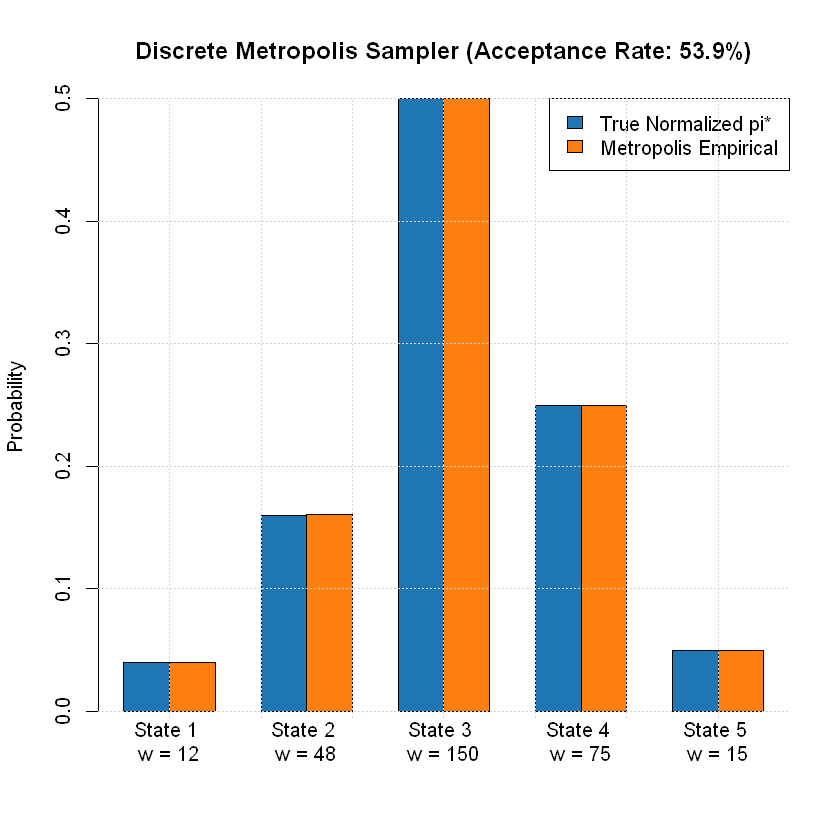

In [5]:
# Demonstration: Discrete Metropolis Sampler in Base R
# Target: Unnormalized weights over 5 states
unnormalized_target <- c(12.0, 48.0, 150.0, 75.0, 15.0)
true_normalized <- unnormalized_target / sum(unnormalized_target)

discrete_metropolis_sample <- function(target_weights, steps = 50000) {
  n_states <- length(target_weights)
  chain <- integer(steps)
  chain[1] <- sample(1:n_states, 1)  # Random start
  accepts <- 0
  
  for (t in 2:steps) {
    curr <- chain[t - 1]
    # Symmetric proposal: jump left (-1) or right (+1) with periodic boundary
    move <- sample(c(-1, 1), 1)
    prop <- ((curr - 1 + move) %% n_states) + 1
    
    # Metropolis acceptance ratio using RAW unnormalized weights
    ratio <- target_weights[prop] / target_weights[curr]
    alpha <- min(1.0, ratio)
    
    if (runif(1) < alpha) {
      chain[t] <- prop
      accepts <- accepts + 1
    } else {
      chain[t] <- curr  # Rejection: stay in place!
    }
  }
  
  return(list(chain = chain, acc_rate = accepts / steps))
}

res <- discrete_metropolis_sample(unnormalized_target, steps = 50000)
empirical_target_freqs <- prop.table(table(factor(res$chain, levels = 1:5)))

# Visual comparison
barplot_data <- rbind(True = true_normalized, Empirical = as.numeric(empirical_target_freqs))
barplot(barplot_data, beside = TRUE, col = c("#1f77b4", "#ff7f0e"),
        names.arg = paste("State", 1:5, "\nw =", unnormalized_target),
        main = sprintf("Discrete Metropolis Sampler (Acceptance Rate: %.1f%%)", res$acc_rate * 100),
        ylab = "Probability")
legend("topright", legend = c("True Normalized pi*", "Metropolis Empirical"),
       fill = c("#1f77b4", "#ff7f0e"))
grid()

cat("--- Comparison: True vs Empirical Frequencies ---\n")
df_comp <- data.frame(
  Raw_Weight = unnormalized_target,
  True_pi = round(true_normalized, 4),
  Empirical = round(as.numeric(empirical_target_freqs), 4),
  Abs_Error = round(abs(as.numeric(empirical_target_freqs) - true_normalized), 4)
)
print(df_comp)

---

## Part 6: Check Your Understanding (3-Tier Scaffolding Exercises)

---

### 🟢 Tier 1 (Conceptual): Why Not Calculate $P(y)$?

**Question**:  
Suppose you are doing Bayesian inference with 10 continuous parameters $\theta = (\theta_1, \dots, \theta_{10})$.  
Why is Detailed Balance $\pi(A) T(A \to B) = \pi(B) T(B \to A)$ the mathematical key that frees us from having to calculate the evidence integral $P(y) = \int \mathcal{L}(y \mid \theta) P(\theta) \, d\theta$?

<details>
<summary><b>🔍 Reveal Answer & Explanation</b></summary>

Because detailed balance only requires the **ratio** of probabilities between two states:
$$\frac{\alpha(A \to B)}{\alpha(B \to A)} = \frac{\pi(B)}{\pi(A)}$$

The evidence integral $P(y)$ is a constant with respect to $\theta$. It appears identically in the numerator and denominator:
$$\frac{\pi(B)}{\pi(A)} = \frac{\frac{\mathcal{L}(y \mid B) P(B)}{P(y)}}{\frac{\mathcal{L}(y \mid A) P(A)}{P(y)}} = \frac{\mathcal{L}(y \mid B) P(B)}{\mathcal{L}(y \mid A) P(A)}$$
$P(y)$ cancels out completely. We only ever need to evaluate the product of the likelihood and the prior, which is $O(1)$ to compute at any single point!
</details>

---

### 🟡 Tier 2 (Guided Calculation): Two-Room Detailed Balance Equilibrium

**Question**:  
Imagine two rooms, Room 1 and Room 2.  
* People in Room 1 have probability $P_{12} = 0.40$ of walking into Room 2.
* People in Room 2 have probability $P_{21} = 0.10$ of walking into Room 1.

Using **Detailed Balance directly**, find the stationary fraction of people in Room 1 ($\\pi_1$) and Room 2 ($\\pi_2$).

<details>
<summary><b>🔍 Reveal Answer & Derivation</b></summary>

1. Write the Detailed Balance condition between Room 1 and Room 2:
   $$\pi_1 \cdot P_{12} = \pi_2 \cdot P_{21}$$
2. Substitute the given transition rates:
   $$\pi_1 \cdot 0.40 = \pi_2 \cdot 0.10 \implies \pi_2 = 4 \pi_1$$
3. Use the normalization constraint $\pi_1 + \pi_2 = 1.0$:
   $$\pi_1 + 4\pi_1 = 1.0 \implies 5\pi_1 = 1.0 \implies \pi_1 = 0.20$$
   $$\pi_2 = 4(0.20) = 0.80$$

**Result**: At equilibrium, **$20\%$** of the people are in Room 1, and **$80\%$** are in Room 2!
</details>

---

### 🔴 Tier 3 (Production Challenge): An Automated Detailed Balance Auditor in R

Write an R function `audit_detailed_balance(P, pi, tol = 1e-5)` that:
1. Verifies that $P$ is a valid transition matrix.
2. Verifies that $\pi$ is a valid probability vector.
3. Verifies that $\pi$ satisfies Global Balance ($\|\pi P - \pi\| < \text{tol}$).
4. Computes the maximum pairwise flow asymmetry:
   $$\Delta_{\max} = \max_{i < j} |\pi_i P_{ij} - \pi_j P_{ji}|$$

In [6]:
# ============================================================
# 🔴 Tier 3: Your Turn — Attempt the Problem Here
# ============================================================

audit_detailed_balance <- function(P, pi, tol = 1e-5) {
  # 1. Row stochasticity: all elements >= 0, rows sum to 1
  # is_valid_P <- ...
  
  # 2. Probability vector: all elements >= 0, sums to 1
  # is_valid_pi <- ...
  
  # 3. Stationarity (Global Balance): pi %*% P == pi
  # is_stationary <- ...
  
  # 4. Detailed Balance (Pairwise Flux): Flow[i, j] == Flow[j, i]
  # max_asymmetry <- ...
  # satisfies_detailed_balance <- ...
  
  # return(list(
  #   valid_P = is_valid_P,
  #   valid_pi = is_valid_pi,
  #   is_stationary = is_stationary,
  #   satisfies_detailed_balance = satisfies_detailed_balance,
  #   max_flux_asymmetry = max_asymmetry,
  #   global_discrepancy = global_discrepancy
  # ))
}

# Test your function when ready:
# cat("=== Test 1: 3-Island Transition Matrix ===\n")
# print(audit_detailed_balance(P, pi_exact))

# cat("\n=== Test 2: Discrete Metropolis Transition Matrix ===\n")
# print(audit_detailed_balance(P_metro, true_normalized))


<details>
<summary><b>🔍 Click here to view the solution, test code & verification results in R</b></summary>

```r
audit_detailed_balance <- function(P, pi, tol = 1e-5) {
  is_valid_P <- all(P >= 0) && isTRUE(all.equal(unname(rowSums(P)), rep(1, nrow(P)), tolerance = tol))
  is_valid_pi <- all(pi >= 0) && isTRUE(all.equal(unname(sum(pi)), 1, tolerance = tol))
  
  global_discrepancy <- max(abs(as.vector(pi %*% P) - pi))
  is_stationary <- global_discrepancy < tol
  
  K <- length(pi)
  Flow <- diag(pi) %*% P
  asymmetries <- c()
  for (i in 1:(K - 1)) {
    for (j in (i + 1):K) {
      asymmetries <- c(asymmetries, abs(Flow[i, j] - Flow[j, i]))
    }
  }
  max_asymmetry <- max(asymmetries)
  satisfies_detailed_balance <- max_asymmetry < tol
  
  return(list(
    valid_P = is_valid_P,
    valid_pi = is_valid_pi,
    is_stationary = is_stationary,
    satisfies_detailed_balance = satisfies_detailed_balance,
    max_flux_asymmetry = max_asymmetry,
    global_discrepancy = global_discrepancy
  ))
}

# Test 1: 3-Island Transition Matrix
cat("=== Test 1: 3-Island Transition Matrix ===\n")
res_islands <- audit_detailed_balance(P, pi_exact)
print(res_islands)

# Test 2: Symmetric Metropolis Transition Matrix from Part 5
P_metro <- matrix(0, nrow = 5, ncol = 5)
for (i in 1:5) {
  for (move in c(-1, 1)) {
    j <- ((i - 1 + move) %% 5) + 1
    q_ij <- 0.5
    alpha_ij <- min(1.0, unnormalized_target[j] / unnormalized_target[i])
    P_metro[i, j] <- q_ij * alpha_ij
  }
  P_metro[i, i] <- 1.0 - sum(P_metro[i, ])
}

cat("\n=== Test 2: Discrete Metropolis Transition Matrix ===\n")
res_metro <- audit_detailed_balance(P_metro, true_normalized)
print(res_metro)
```

**Console Output**:
```text
=== Test 1: 3-Island Transition Matrix ===
$valid_P
[1] TRUE

$valid_pi
[1] TRUE

$is_stationary
[1] TRUE

$satisfies_detailed_balance
[1] FALSE

$max_flux_asymmetry
[1] 0.05747126

$global_discrepancy
[1] 0

=== Test 2: Discrete Metropolis Transition Matrix ===
$valid_P
[1] TRUE

$valid_pi
[1] TRUE

$is_stationary
[1] TRUE

$satisfies_detailed_balance
[1] TRUE

$max_flux_asymmetry
[1] 0

$global_discrepancy
[1] 0
```

**Key Pedagogical Takeaways**:
* **Audit 1 (The 3-Island Matrix)**: Easily satisfies **Global Balance** (`is_stationary = TRUE`, discrepancy = 0), but **fails Detailed Balance** (`satisfies_detailed_balance = FALSE`, maximum asymmetry $\approx 0.0575$). This proves empirically that a stationary distribution does *not* imply detailed balance—unbalanced circular currents persist!
* **Audit 2 (The Discrete Metropolis Sampler)**: Satisfies both Global Balance AND Detailed Balance down to machine precision (`max_flux_asymmetry ~ 0`). The Metropolis acceptance rule $\alpha = \min(1, \pi(B)/\pi(A))$ guarantees pairwise equilibrium across every individual state transition!
</details>

---

## 🚀 Looking Ahead: Bridging from Discrete States to Continuous Parameters

You now possess the foundational mathematical concepts required to master MCMC:
1. **The Markov Chain**: A memoryless sequence of states.
2. **The Transition Kernel**: The rule governing moves.
3. **The Stationary Distribution**: The equilibrium invariant distribution $\pi P = \pi$.
4. **Detailed Balance**: Pairwise equilibrium $\pi(A) T(A \to B) = \pi(B) T(B \to A)$.
5. **The Metropolis Engine**: How accepting proposals with probability $\min\left(1, \frac{\pi(B)}{\pi(A)}\right)$ forces detailed balance to hold, enabling us to sample from unnormalized posteriors!

In **[Sheet 4: First Principles — MCMC Mechanics from Scratch](04_mcmc_mechanics_from_scratch.ipynb)**, we generalize these discrete concepts to **continuous multidimensional parameter spaces $\theta \in \mathbb{R}^D$**:
* Instead of jumping between 3 islands, our walker hops smoothly along continuous curves.
* Instead of a transition matrix $P_{ij}$, we use a continuous proposal density $q(\theta^* \mid \theta^{(t)}) = \mathcal{N}(\theta^{(t)}, \tau^2)$.
* The core Metropolis rule remains **100% identical**.

---

**[🏠 Course Home](00_START_HERE.ipynb) | ◀️ Previous: [Sheet 3: Rapid Prototyping — Quadratic (Laplace / QUAP) Approximation](03_quadratic_laplace_approximation.ipynb) | ▶️ Next: [Sheet 4: First Principles — MCMC Mechanics from Scratch](04_mcmc_mechanics_from_scratch.ipynb)**